In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import binary_erosion
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, iradon, resize

**Parameters**

In [2]:
N = 128                                             # image size (N x N pixels)
C = N // 2                                          # rotation centre used by skimage.radon
THETA = np.linspace(0., 180., 180, endpoint=False)  # projection angles: one per degree, 0-179°
FILTERS = ["ramp", "shepp-logan", "cosine", "hamming", "hann"]
COUNTS = None                                       # Step 3 data: None = noise-free; e.g. 2e5 = Poisson noise
COUNT_LEVELS = [1e4, 1e5, 1e6]                      # Steps 4 and 6: total counts of the noisy sinograms
N_ITER = 100                                        # MLEM iterations
SEED = 0                                            # random seed for Poisson noise (reproducible)
FBP_CUTOFFS = [0.1, 0.15, 0.25, 0.35, 0.5, 0.75, 1.0]  # Step 7: Hann cut-off, fraction of Nyquist
MLEM_ITERS = [2, 3, 5, 7, 10, 15, 20, 30, 50, 100]  # Step 7: MLEM iterations to record
N_REAL = 10                                         # Step 7: independent noise realisations per setting

**Functions**

In [3]:
def fov_mask(n=N):
    """True inside the circular field of view (same circle skimage.radon assumes)."""
    yy, xx = np.mgrid[:n, :n] - n // 2
    return xx**2 + yy**2 <= (n // 2) ** 2

In [4]:
def make_phantom(n=N):
  """Shepp-Logan phantom resized to n x n, zero outside the field of view."""
  img = resize(shepp_logan_phantom(), (n, n))
  img[~fov_mask(n)] = 0
  return img

In [5]:
def add_poisson_noise(sino, counts, rng=None):
    """Scale a noise-free sinogram so its total is `counts`, then draw Poisson counts.
    Returns (y, k): y is in COUNTS (integers), k = counts / sino.sum() is the scale factor.
    Divide by k to return to the units of the phantom."""
    rng = rng or np.random.default_rng(SEED)
    k = counts / sino.sum()
    return rng.poisson(sino * k).astype(float), k


In [6]:
def simulate(truth, counts=None, rng=None):
  """Sinogram of `truth`, in the units of the phantom.
  counts=None -> noise-free; otherwise Poisson noise with `counts` total events
  (generated by add_poisson_noise, so SEED applies here too), rescaled back."""
  sino = radon(truth, theta=THETA, circle=True)
  if counts is None:
    return sino
  y, k = add_poisson_noise(sino, counts, rng)
  return y / k

In [7]:
def plot_phantom_sinogram(phantom, sinogram, fname="phantom_sinogram.png"):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.8))

  im1 = ax1.imshow(phantom, cmap="gray")
  ax1.set_title("Shepp-Logan phantom")
  ax1.set_xlabel("x (pixel)"); ax1.set_ylabel("y (pixel)")
  fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label="Activity (a.u.)")

  n_det = sinogram.shape[0]
  d_theta = THETA[1] - THETA[0]
  s_min, s_max = -(n_det // 2), n_det - 1 - n_det // 2
  im2 = ax2.imshow(sinogram, cmap="gray", aspect="auto",
            extent=(THETA[0] - d_theta / 2, THETA[-1] + d_theta / 2,  # left, right
                s_max + 0.5, s_min - 0.5))
  ax2.set_title("Sinogram (Radon transform)")
  ax2.set_xlabel("Projection angle θ (degrees)")
  ax2.set_ylabel("Detector position s (pixel)")
  fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label="Line integral (a.u.)")

  plt.tight_layout()
  plt.savefig(fname, dpi=150)
  plt.show()

B.  FBP reconstruction

Perform FBP reconstruction using each of the five filters

In [8]:
def fbp(sino, filter_name):
  img = iradon(sino, theta=THETA, filter_name=filter_name,
          circle=True, output_size=N)
  img[~fov_mask()] = 0
  return img

In [9]:
def make_rois(n=N, erode=3):
  """Boolean masks (hot, bkg); see the markdown cell above."""
  lab = np.round(resize(shepp_logan_phantom(), (n, n), order=0,
              anti_aliasing=False), 1)
  upper_half = np.arange(n)[:, None] < n // 2      # row index < n/2, broadcast over columns
  hot = (lab == 0.3) & upper_half                   # only the large upper ellipse
  bkg = lab == 0.2
  st = np.ones((3, 3), bool)
  return (binary_erosion(hot, st, iterations=erode),
      binary_erosion(bkg, st, iterations=erode))

Metrics: NRMSE, CR, SD_bkg, COV_bkg

In [10]:
def nrmse(recon, truth, mask=None):
  """RMSE / RMS(truth) inside `mask` (default: field of view). 0 = perfect."""
  m = fov_mask() if mask is None else mask
  return np.sqrt(np.mean((recon[m] - truth[m]) ** 2)) / np.sqrt(np.mean(truth[m] ** 2))


def contrast_recovery(recon, truth, hot, bkg):
  """CR = (hot/bkg - 1)_recon / (hot/bkg - 1)_truth. 1 = contrast fully recovered."""
  c_rec = recon[hot].mean() / recon[bkg].mean() - 1
  c_true = truth[hot].mean() / truth[bkg].mean() - 1
  return c_rec / c_true


def uniform_std(recon, bkg):
  """Standard deviation in the uniform region (same units as the image)."""
  return recon[bkg].std()


def evaluate(recon, truth, hot, bkg):
  sd = uniform_std(recon, bkg)
  return {"NRMSE": nrmse(recon, truth),
      "CR": contrast_recovery(recon, truth, hot, bkg),
      "SD_bkg": sd,
      "COV_bkg": sd / recon[bkg].mean(),
      "bkg_mean": recon[bkg].mean()}


def plot_fbp_eval(truth, recons, results, hot, bkg, title, fname):
  fig, ax = plt.subplots(2, 6, figsize=(18, 6.4))

  ax[0, 0].imshow(truth, cmap="gray", vmin=0, vmax=1)
  ax[0, 0].contour(hot, levels=[0.5], colors="r", linewidths=1)
  ax[0, 0].contour(bkg, levels=[0.5], colors="c", linewidths=1)
  ax[0, 0].set_title("Truth + ROIs\n(red: hot, cyan: uniform)")

  s = np.arange(N) - C
  ax[1, 0].plot(s, truth[:, C], "k", lw=2, label="Truth")
  for f in ["ramp", "hann"]:
    ax[1, 0].plot(s, recons[f][:, C], lw=1, label=f)
  ax[1, 0].set_title("Vertical profile through centre")
  ax[1, 0].set_xlabel("y (pixel)"); ax[1, 0].set_ylim(-0.1, 1.1)
  ax[1, 0].legend(fontsize=8)

  for j, f in enumerate(FILTERS, start=1):
    r = results[f]
    ax[0, j].imshow(recons[f], cmap="gray", vmin=0, vmax=1)
    ax[0, j].set_title(f"{f}\nNRMSE={r['NRMSE']:.3f}  CR={r['CR']:.2f}")
    im = ax[1, j].imshow(recons[f] - truth, cmap="RdBu_r", vmin=-0.3, vmax=0.3)
    ax[1, j].set_title(f"Error (recon - truth)\nSD_bkg={r['SD_bkg']:.4f}")

  for a in ax.flat:
    if a is not ax[1, 0]:
      a.axis("off")
  fig.colorbar(im, ax=ax[1, 1:].tolist(), fraction=0.02, pad=0.01, label="Error")
  fig.suptitle(title, fontsize=13)
  plt.savefig(fname, dpi=110, bbox_inches="tight")
  plt.show()

MLEM

In [11]:
def forward(x):
  """A: image -> sinogram."""
  return radon(x, theta=THETA, circle=True)


def backproject(y):
  """A^T (up to a constant factor): sinogram -> image, no filtering."""
  return iradon(y, theta=THETA, filter_name=None, circle=True, output_size=N)


def mlem(y, n_iter, truth=None, k=1.0):
  """
  MLEM reconstruction of sinogram `y`.
    truth, k : if `truth` is given, NRMSE(x / k, truth) is recorded every iteration.
          k converts the reconstruction from counts back to phantom units.
  Returns (images, nrmse_history, loglik_history).
    images[j]  = x after j+1 iterations
    loglik[j]  = Poisson log-likelihood of the image entering iteration j+1
  """
  fov = fov_mask()
  sens = backproject(np.ones_like(y))                      # A^T 1
  x = fov.astype(float)                                    # start: uniform inside FOV
  images, errs, loglik = [], [], []
  for _ in range(n_iter):
    y_est = forward(x)                                   # A x
    loglik.append(np.sum(y * np.log(np.maximum(y_est, 1e-12)) - y_est))
    ratio = np.divide(y, y_est, out=np.zeros_like(y), where=y_est > 0)  # y / (A x)
    x = np.where(fov, x * backproject(ratio) / np.where(sens > 0, sens, 1), 0)
    images.append(x)
    if truth is not None:
      errs.append(nrmse(x / k, truth))
  return images, np.array(errs), np.array(loglik)

FBP with cut-off

In [12]:
def ramp_hann_filter(n_det, cutoff=None):
    """Frequency response of the ramp filter, optionally times a Hann window.
    The ramp is built in the spatial domain (Kak & Slaney), exactly as skimage does,
    so cutoff=None reproduces iradon(filter_name="ramp").
    cutoff: fraction of Nyquist (0-1]; the window is 0 above it."""
    size = max(64, int(2 ** np.ceil(np.log2(2 * n_det))))
    n = np.concatenate((np.arange(1, size / 2 + 1, 2, dtype=int),
                        np.arange(size / 2 - 1, 0, -2, dtype=int)))
    h = np.zeros(size)
    h[0] = 0.25
    h[1::2] = -1 / (np.pi * n) ** 2
    H = 2 * np.real(np.fft.fft(h))
    if cutoff is not None:
        nu = np.abs(np.fft.fftfreq(size)) * 2                # 1 = Nyquist
        H *= np.where(nu <= cutoff, 0.5 * (1 + np.cos(np.pi * nu / cutoff)), 0.0)
    return H


def fbp_cutoff(sino, cutoff=None):
    """FBP with a Hann-windowed ramp filter at the given cut-off.
    Pads the sinogram to the image diagonal (as skimage does), filters, then
    backprojects with iradon(filter_name=None)."""
    n = sino.shape[0]
    diag = int(np.ceil(np.sqrt(2) * n))
    before = diag // 2 - n // 2
    sq = np.pad(sino, ((before, diag - n - before), (0, 0)))
    H = ramp_hann_filter(diag, cutoff)
    P = np.fft.fft(np.pad(sq, ((0, len(H) - diag), (0, 0))), axis=0)
    filtered = np.real(np.fft.ifft(P * H[:, None], axis=0))[:diag]
    img = iradon(filtered, theta=THETA, filter_name=None, circle=False, output_size=N)
    img[~fov_mask()] = 0
    return img


def run_experiment(truth, hot, bkg):
    """For every count level and every noise realisation: draw one Poisson sinogram,
    reconstruct it with every FBP cut-off and with MLEM (recording the images at
    MLEM_ITERS), and evaluate. Both algorithms see the SAME noisy data (paired design).
    Returns one row per (counts, realisation, method, parameter)."""
    clean = forward(truth)
    rows = []
    for ci, c in enumerate(COUNT_LEVELS):
        for r in range(N_REAL):
            rng = np.random.default_rng([SEED, ci, r])      # independent, reproducible stream
            y, k = add_poisson_noise(clean, c, rng=rng)
            for fc in FBP_CUTOFFS:
                m = evaluate(fbp_cutoff(y / k, fc), truth, hot, bkg)
                rows.append(dict(counts=c, real=r, method="FBP", param=fc, **m))
            imgs, _, _ = mlem(y, max(MLEM_ITERS))
            for it in MLEM_ITERS:
                m = evaluate(imgs[it - 1] / k, truth, hot, bkg)
                rows.append(dict(counts=c, real=r, method="MLEM", param=it, **m))
        print(f"{c:.0e} counts: {N_REAL} realisations done")
    return pd.DataFrame(rows)

**Main**

Step1. Phantom and sinogram
Step2. Regions of interest
Step3. FBP with each filter, and evaluation

Phantom shape:  (128, 128)
Sinogram shape: (128, 180)  (detector bins x angles)


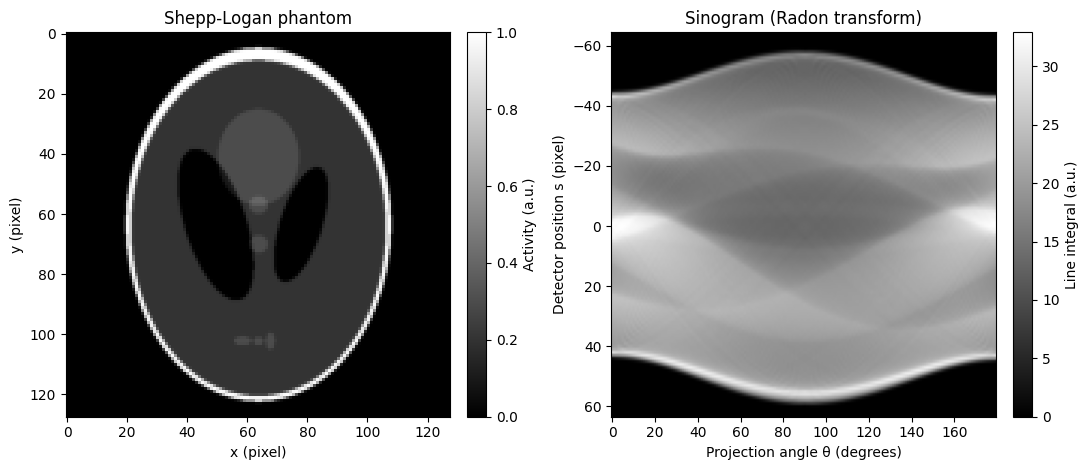

Hot ROI: 330 px, uniform ROI: 3183 px
Truth: hot mean = 0.298, uniform mean = 0.200
filter         NRMSE      CR   SD_bkg  COV_bkg  bkg mean
ramp           0.136   1.001   0.0029    0.014     0.200
shepp-logan    0.158   1.001   0.0022    0.011     0.200
cosine         0.203   1.001   0.0012    0.006     0.200
hamming        0.238   1.001   0.0009    0.005     0.200
hann           0.247   1.001   0.0008    0.004     0.200


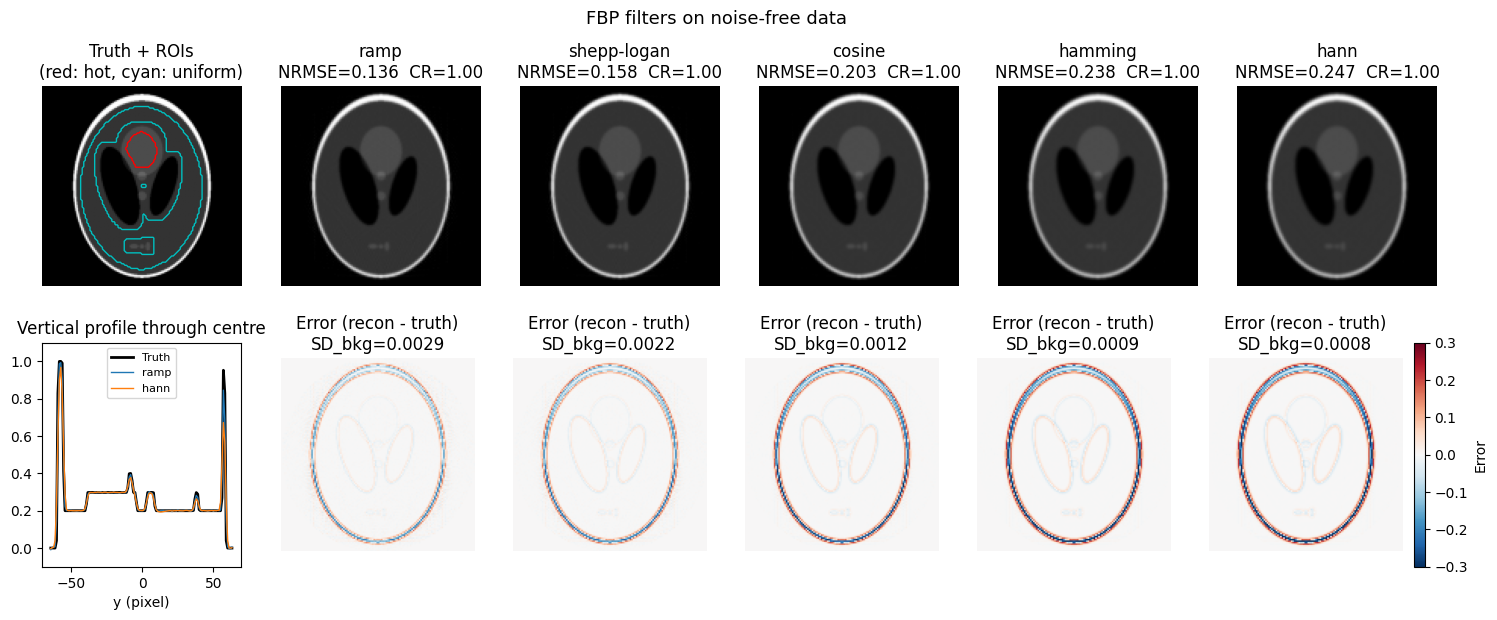

In [13]:
phantom = make_phantom()
sinogram_clean = simulate(phantom)                  # always noise-free for this figure
print(f"Phantom shape:  {phantom.shape}")
print(f"Sinogram shape: {sinogram_clean.shape}  (detector bins x angles)")
plot_phantom_sinogram(phantom, sinogram_clean)

hot, bkg = make_rois()
print(f"Hot ROI: {hot.sum()} px, uniform ROI: {bkg.sum()} px")
print(f"Truth: hot mean = {phantom[hot].mean():.3f}, uniform mean = {phantom[bkg].mean():.3f}")

sinogram = sinogram_clean if COUNTS is None else simulate(phantom, counts=COUNTS)

recons, results = {}, {}
print(f"{'filter':12s} {'NRMSE':>7s} {'CR':>7s} {'SD_bkg':>8s} {'COV_bkg':>8s} {'bkg mean':>9s}")
for f in FILTERS:
  recons[f] = fbp(sinogram, f)
  results[f] = r = evaluate(recons[f], phantom, hot, bkg)
  print(f"{f:12s} {r['NRMSE']:7.3f} {r['CR']:7.3f} {r['SD_bkg']:8.4f} "
      f"{r['COV_bkg']:8.3f} {r['bkg_mean']:9.3f}")

tag = "noisefree" if COUNTS is None else f"counts{int(COUNTS)}"
title = ("FBP filters on noise-free data" if COUNTS is None
      else f"FBP filters, Poisson noise ({COUNTS:.0e} counts)")
plot_fbp_eval(phantom, recons, results, hot, bkg, title, f"fbp_eval_{tag}.png")

Step4. Poisson noise at 10^4, 10^5 and 10^6 counts

    1e+04 counts: total =     10052, mean per bin =    0.44, max per bin =     5, zero bins = 66.2%
    1e+05 counts: total =     99680, mean per bin =    4.33, max per bin =    20, zero bins = 19.3%
    1e+06 counts: total =   1000989, mean per bin =   43.45, max per bin =   122, zero bins = 17.7%


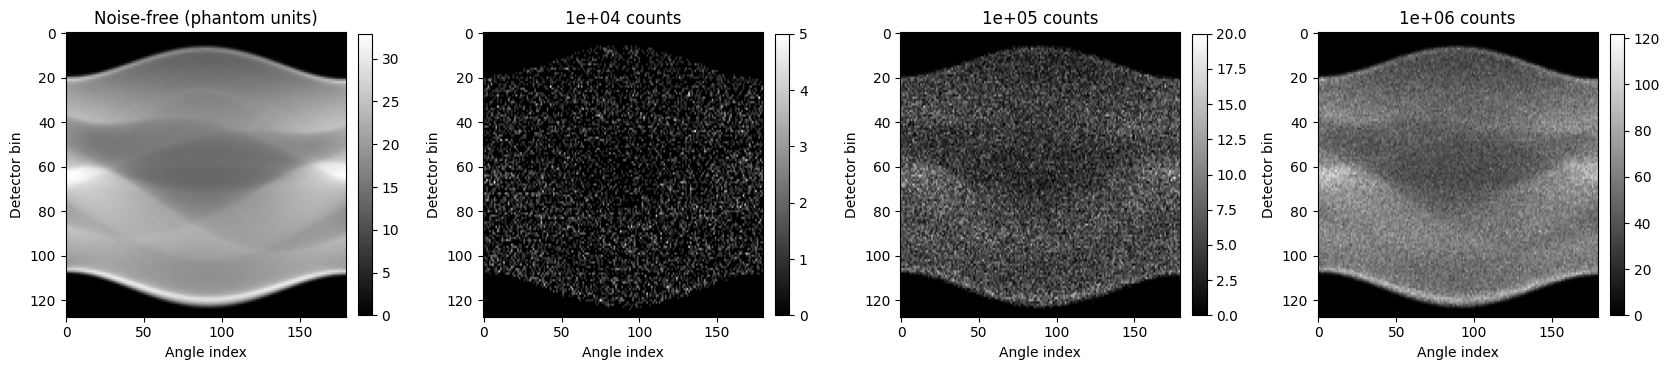

In [14]:
noisy = {}                                          # counts -> (y in counts, scale k)
for c in COUNT_LEVELS:
  noisy[c] = add_poisson_noise(sinogram_clean, c, rng=np.random.default_rng(SEED))
  y, k = noisy[c]
  print(f"{c:9.0e} counts: total = {y.sum():9.0f}, mean per bin = {y.mean():7.2f}, "
    f"max per bin = {y.max():5.0f}, zero bins = {100 * (y == 0).mean():4.1f}%")

fig, ax = plt.subplots(1, 1 + len(COUNT_LEVELS), figsize=(4.2 * (1 + len(COUNT_LEVELS)), 3.8))
panels = [("Noise-free (phantom units)", sinogram_clean)] + \
    [(f"{c:.0e} counts", noisy[c][0]) for c in COUNT_LEVELS]
for a, (t, img) in zip(ax, panels):
  im = a.imshow(img, cmap="gray", aspect="auto")
  a.set_title(t); a.set_xlabel("Angle index"); a.set_ylabel("Detector bin")
  fig.colorbar(im, ax=a, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("noisy_sinograms.png", dpi=110)
plt.show()

Step 5. MLEM: validation on noise free data

In [15]:
rng = np.random.default_rng(1)
fov = fov_mask()
print(f"Expected constant 2*n_angles/pi = {2 * len(THETA) / np.pi:.3f}")
for i in range(3):
  xr = rng.random((N, N)) * fov
  yr = rng.random((N, len(THETA)))
  print(f"  draw {i + 1}: <Ax, y> / <x, A^T y> = "
    f"{np.vdot(forward(xr), yr) / np.vdot(xr, backproject(yr)):.3f}")

Expected constant 2*n_angles/pi = 114.592
  draw 1: <Ax, y> / <x, A^T y> = 114.543
  draw 2: <Ax, y> / <x, A^T y> = 114.548
  draw 3: <Ax, y> / <x, A^T y> = 114.544


NRMSE: 0.728 (iter 1) -> 0.357 (iter 10) -> 0.062 (iter 100)
Iterations where NRMSE went UP:           0
Iterations where log-likelihood went DOWN: 0
PASS: MLEM is monotone on noise-free data


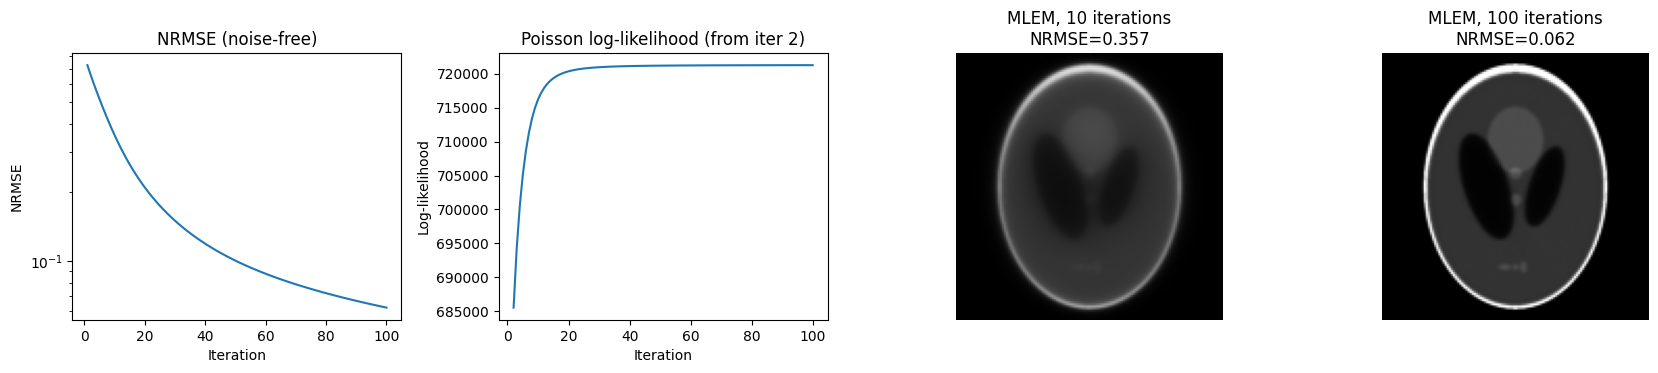

In [16]:
imgs_clean, err_clean, ll_clean = mlem(sinogram_clean, N_ITER, truth=phantom)

n_err_up = int((np.diff(err_clean) > 0).sum())
n_ll_down = int((np.diff(ll_clean) < 0).sum())
print(f"NRMSE: {err_clean[0]:.3f} (iter 1) -> {err_clean[9]:.3f} (iter 10) "
  f"-> {err_clean[-1]:.3f} (iter {N_ITER})")
print(f"Iterations where NRMSE went UP:           {n_err_up}")
print(f"Iterations where log-likelihood went DOWN: {n_ll_down}")
assert n_err_up == 0 and n_ll_down == 0, "MLEM is not monotone on noise-free data: bug"
print("PASS: MLEM is monotone on noise-free data")

fig, ax = plt.subplots(1, 4, figsize=(17, 3.8))
it = np.arange(1, N_ITER + 1)
ax[0].plot(it, err_clean); ax[0].set_yscale("log")
ax[0].set_xlabel("Iteration"); ax[0].set_ylabel("NRMSE"); ax[0].set_title("NRMSE (noise-free)")
ax[1].plot(it[1:], ll_clean[1:])                 # skip the uniform start image, which dwarfs the rest
ax[1].set_xlabel("Iteration"); ax[1].set_ylabel("Log-likelihood")
ax[1].set_title("Poisson log-likelihood (from iter 2)")
for a, j in zip(ax[2:], [9, N_ITER - 1]):
  a.imshow(imgs_clean[j], cmap="gray", vmin=0, vmax=1)
  a.set_title(f"MLEM, {j + 1} iterations\nNRMSE={err_clean[j]:.3f}"); a.axis("off")
plt.tight_layout()
plt.savefig("mlem_noisefree.png", dpi=110)
plt.show()

Step 6. MLEM vs FBP on noisy data

In [17]:
mlem_runs, table = {}, []
for c in COUNT_LEVELS:
  y, k = noisy[c]
  imgs, errs, _ = mlem(y, N_ITER, truth=phantom, k=k)
  best = int(np.argmin(errs))
  mlem_runs[c] = (imgs, errs, best)
  fbp_ramp, fbp_hann = fbp(y / k, "ramp"), fbp(y / k, "hann")
  for name, img in [("FBP ramp", fbp_ramp), ("FBP hann", fbp_hann),
            (f"MLEM best (it {best + 1})", imgs[best] / k),
            (f"MLEM it {N_ITER}", imgs[-1] / k)]:
    table.append((c, name, img, evaluate(img, phantom, hot, bkg)))

print(f"{'counts':>7s}  {'method':20s} {'NRMSE':>7s} {'CR':>7s} {'SD_bkg':>8s} {'bkg mean':>9s}")
for c, name, _, r in table:
  print(f"{c:7.0e}  {name:20s} {r['NRMSE']:7.3f} {r['CR']:7.3f} {r['SD_bkg']:8.4f} {r['bkg_mean']:9.3f}")

 counts  method                 NRMSE      CR   SD_bkg  bkg mean
  1e+04  FBP ramp               4.424   1.552   1.2374     0.206
  1e+04  FBP hann               1.669   1.526   0.4607     0.204
  1e+04  MLEM best (it 6)       0.589   0.755   0.0983     0.204
  1e+04  MLEM it 100            2.221   1.047   0.6458     0.205
  1e+05  FBP ramp               1.433   1.169   0.3945     0.201
  1e+05  FBP hann               0.585   1.194   0.1480     0.198
  1e+05  MLEM best (it 14)      0.388   0.995   0.0670     0.200
  1e+05  MLEM it 100            0.998   1.142   0.2804     0.198
  1e+06  FBP ramp               0.467   1.026   0.1216     0.200
  1e+06  FBP hann               0.300   1.014   0.0464     0.200
  1e+06  MLEM best (it 31)      0.214   1.056   0.0385     0.196
  1e+06  MLEM it 100            0.340   1.017   0.0939     0.199


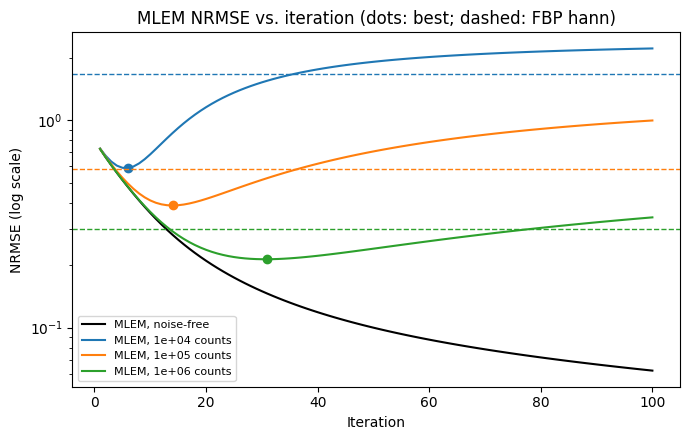

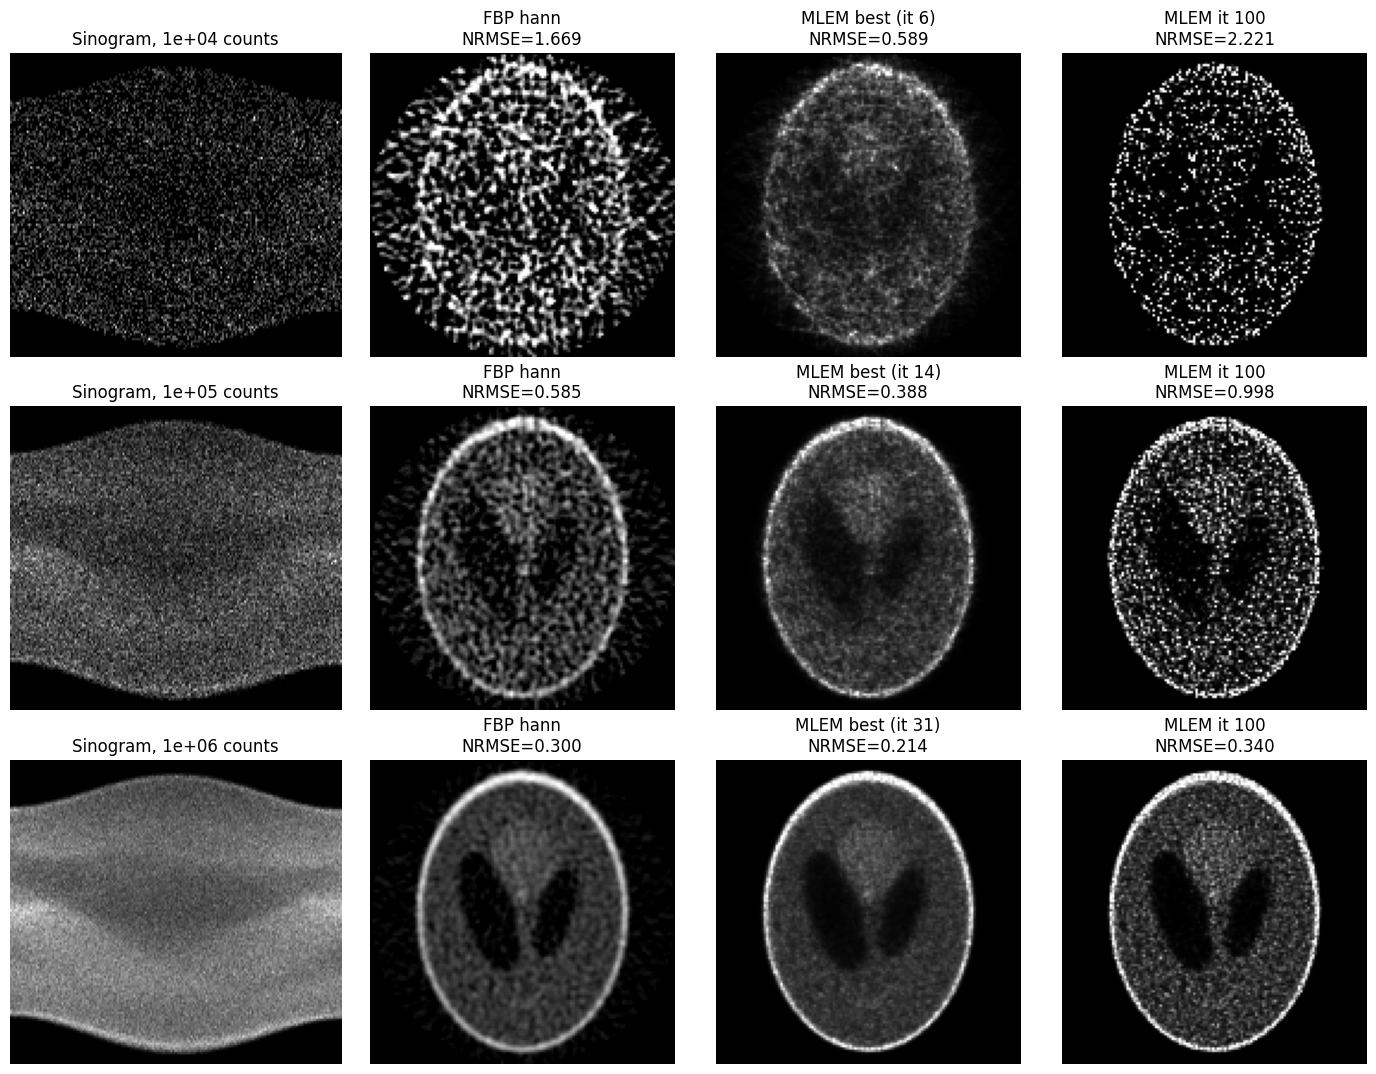

In [18]:
# NRMSE vs. iteration
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
fig, ax = plt.subplots(figsize=(7, 4.5))
it = np.arange(1, N_ITER + 1)
ax.plot(it, err_clean, color="k", label="MLEM, noise-free")
for col, c in zip(colors, COUNT_LEVELS):
  imgs, errs, best = mlem_runs[c]
  ax.plot(it, errs, color=col, label=f"MLEM, {c:.0e} counts")
  ax.plot(best + 1, errs[best], "o", color=col)
  fbp_hann_err = [r["NRMSE"] for cc, n, _, r in table if cc == c and n == "FBP hann"][0]
  ax.axhline(fbp_hann_err, color=col, ls="--", lw=1)
ax.set_xlabel("Iteration"); ax.set_ylabel("NRMSE (log scale)"); ax.set_yscale("log")
ax.set_title("MLEM NRMSE vs. iteration (dots: best; dashed: FBP hann)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("mlem_nrmse_curves.png", dpi=110)
plt.show()

# Images: one row per count level
methods = ["FBP hann", "MLEM best", f"MLEM it {N_ITER}"]
fig, ax = plt.subplots(len(COUNT_LEVELS), 4, figsize=(14, 3.6 * len(COUNT_LEVELS)))
for row, c in zip(ax, COUNT_LEVELS):
  row[0].imshow(noisy[c][0], cmap="gray", aspect="auto")
  row[0].set_title(f"Sinogram, {c:.0e} counts")
  entries = [e for e in table if e[0] == c and not e[1].startswith("FBP ramp")]
  for a, (_, name, img, r) in zip(row[1:], entries):
    a.imshow(img, cmap="gray", vmin=0, vmax=1)
    a.set_title(f"{name}\nNRMSE={r['NRMSE']:.3f}")
  for a in row:
    a.axis("off")
plt.tight_layout()
plt.savefig("mlem_vs_fbp.png", dpi=110)
plt.show()

Step 7. Systematic experiment: counts × algorithm × parameter, 10 noise realisations

check the cut-off FBP against skimage

In [19]:
ref = fbp(sinogram_clean, "ramp")
diff = np.abs(fbp_cutoff(sinogram_clean, None) - ref).max() / ref.max()
print(f"fbp_cutoff(cutoff=None) vs iradon ramp: max relative difference = {diff:.1e}")
assert diff < 1e-10, "fbp_cutoff does not reproduce skimage's ramp FBP"

fbp_cutoff(cutoff=None) vs iradon ramp: max relative difference = 2.5e-15


run experiment

In [20]:
import time
t0 = time.time()
df = run_experiment(phantom, hot, bkg)
print(f"{len(df)} rows in {time.time() - t0:.0f} s")

1e+04 counts: 10 realisations done
1e+05 counts: 10 realisations done
1e+06 counts: 10 realisations done
510 rows in 437 s


Result, including mean and sd.

In [21]:
summary = (df.groupby(["counts", "method", "param"])[["NRMSE", "CR", "SD_bkg"]]
        .agg(["mean", "std"]))

def fmt(col, d=3):
  return (summary[(col, "mean")].map(f"{{:.{d}f}}".format) + " ± "
        + summary[(col, "std")].map(f"{{:.{d}f}}".format))

table = pd.DataFrame({"NRMSE": fmt("NRMSE"), "CR": fmt("CR"), "SD_bkg": fmt("SD_bkg", 4)})
table.index = pd.MultiIndex.from_tuples(
  [(f"{c:.0e}", m, f"{p:g}") for c, m, p in table.index],
  names=["counts", "method", "cut-off / iterations"])
pd.set_option("display.max_rows", 200)
table

NRMSE             CR  \
counts method cut-off / iterations                                 
1e+04  FBP    0.1                   0.689 ± 0.001  0.331 ± 0.161   
              0.15                  0.647 ± 0.002  0.590 ± 0.225   
              0.25                  0.603 ± 0.004  0.911 ± 0.300   
              0.35                  0.622 ± 0.009  1.045 ± 0.330   
              0.5                   0.768 ± 0.013  1.090 ± 0.341   
              0.75                  1.192 ± 0.016  1.127 ± 0.354   
              1                     1.689 ± 0.017  1.170 ± 0.366   
       MLEM   2                     0.671 ± 0.002  0.313 ± 0.096   
              3                     0.628 ± 0.003  0.394 ± 0.133   
              5                     0.586 ± 0.004  0.510 ± 0.190   
              7                     0.598 ± 0.007  0.610 ± 0.230   
              10                    0.693 ± 0.011  0.743 ± 0.271   
              15                    0.934 ± 0.020  0.897 ± 0.308   
              20                    1.177 ± 0.028  0.968 ± 0.325   
              30                    1.554 ± 0.037  0.995 ± 0.337   
              50                    1.954 ± 0.039  0.989 ± 0.348   
              100                   2.262 ± 0.038  0.992 ± 0.366   
1e+05  FBP    0.1                   0.688 ± 0.001  0.356 ± 0.041   
              0.15                  0.640 ± 0.001  0.586 ± 0.059   
              0.25                  0.562 ± 0.001  0.873 ± 0.083   
              0.35                  0.500 ± 0.003  0.981 ± 0.094   
              0.5                   0.449 ± 0.004  0.999 ± 0.099   
              0.75                  0.474 ± 0.006  0.990 ± 0.103   
              1                     0.583 ± 0.006  0.985 ± 0.108   
       MLEM   2                     0.665 ± 0.001  0.318 ± 0.025   
              3                     0.611 ± 0.001  0.396 ± 0.035   
              5                     0.524 ± 0.002  0.502 ± 0.050   
              7                     0.461 ± 0.002  0.591 ± 0.061   
              10                    0.404 ± 0.002  0.714 ± 0.073   
              15                    0.381 ± 0.003  0.868 ± 0.086   
              20                    0.409 ± 0.005  0.953 ± 0.094   
              30                    0.508 ± 0.009  0.997 ± 0.103   
              50                    0.701 ± 0.012  0.964 ± 0.114   
              100                   0.993 ± 0.014  0.924 ± 0.127   
1e+06  FBP    0.1                   0.688 ± 0.000  0.350 ± 0.012   
              0.15                  0.639 ± 0.000  0.580 ± 0.021   
              0.25                  0.557 ± 0.000  0.867 ± 0.033   
              0.35                  0.486 ± 0.001  0.980 ± 0.040   
              0.5                   0.404 ± 0.001  1.005 ± 0.046   
              0.75                  0.324 ± 0.001  1.004 ± 0.050   
              1                     0.298 ± 0.001  1.006 ± 0.053   
       MLEM   2                     0.664 ± 0.000  0.314 ± 0.009   
              3                     0.609 ± 0.001  0.392 ± 0.013   
              5                     0.517 ± 0.001  0.499 ± 0.019   
              7                     0.444 ± 0.001  0.591 ± 0.025   
              10                    0.362 ± 0.001  0.719 ± 0.032   
              15                    0.279 ± 0.002  0.885 ± 0.041   
              20                    0.237 ± 0.002  0.983 ± 0.047   
              30                    0.213 ± 0.002  1.048 ± 0.053   
              50                    0.239 ± 0.004  1.038 ± 0.058   
              100                   0.339 ± 0.005  1.010 ± 0.064   

                                             SD_bkg  
counts method cut-off / iterations                   
1e+04  FBP    0.1                   0.0364 ± 0.0033  
              0.15                  0.0447 ± 0.0038  
              0.25                  0.0697 ± 0.0059  
              0.35                  0.1088 ± 0.0078  
              0.5                   0.1797 ± 0.0079  
              0.75                  0.3171 ± 0.0096  
       

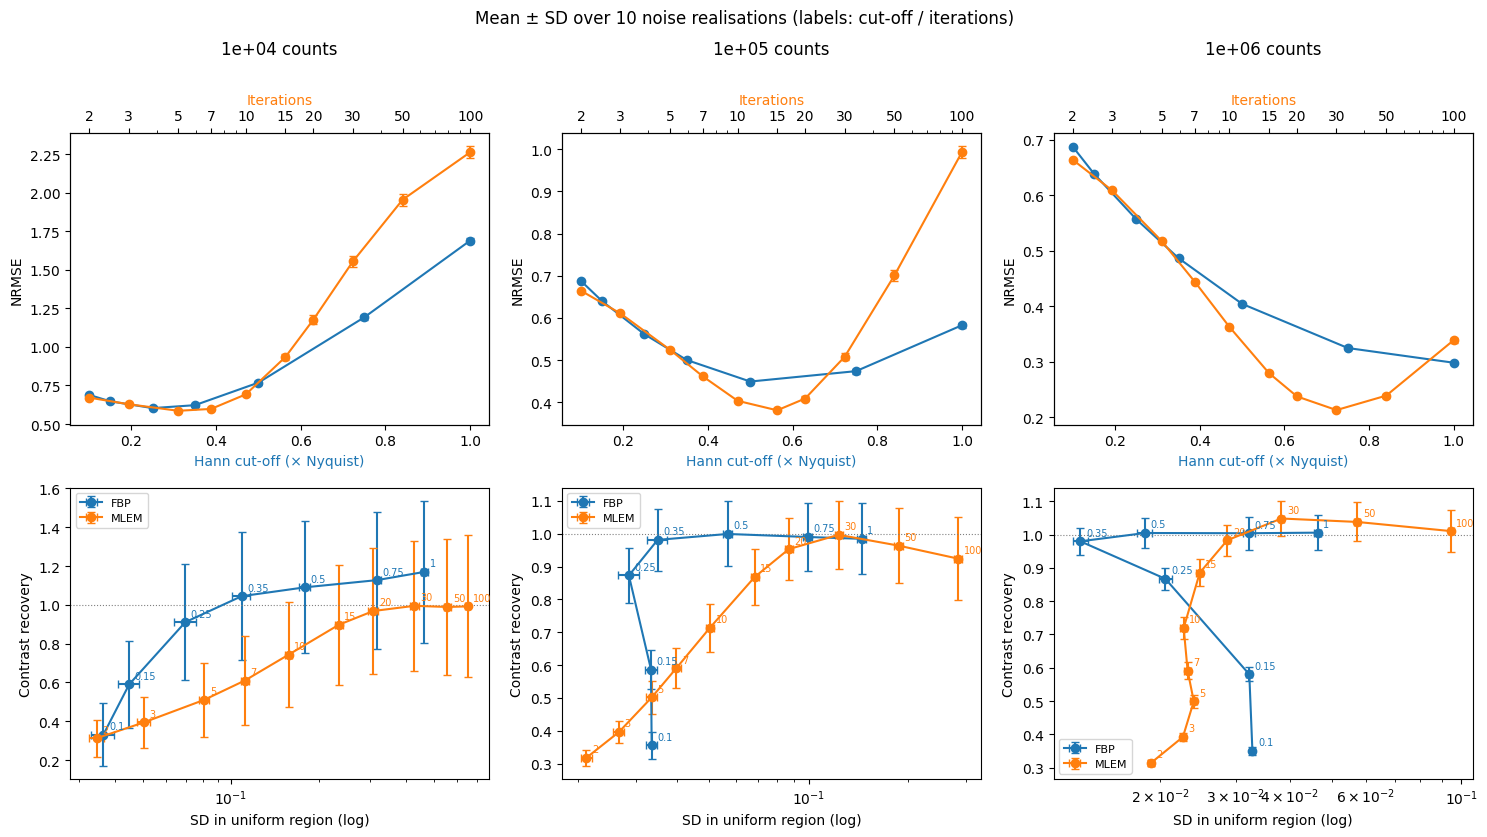

In [22]:
fig, ax = plt.subplots(2, len(COUNT_LEVELS), figsize=(5 * len(COUNT_LEVELS), 8.5))
for j, c in enumerate(COUNT_LEVELS):
  for method, xlab, col in [("FBP", "Hann cut-off (× Nyquist)", "C0"), ("MLEM", "Iterations", "C1")]:
    s = summary.loc[(c, method)]
    a = ax[0, j] if method == "FBP" else ax[0, j].twiny()
    a.errorbar(s.index, s[("NRMSE", "mean")], yerr=s[("NRMSE", "std")],
          marker="o", capsize=3, color=col, label=method)
    a.set_xlabel(xlab, color=col)
    if method == "MLEM":
      a.set_xscale("log"); a.set_xticks(MLEM_ITERS); a.set_xticklabels(MLEM_ITERS)
    # noise-contrast trade-off
    ax[1, j].errorbar(s[("SD_bkg", "mean")], s[("CR", "mean")],
            xerr=s[("SD_bkg", "std")], yerr=s[("CR", "std")],
            marker="o", capsize=3, color=col, label=method)
    for p, row in s.iterrows():
      ax[1, j].annotate(f"{p:g}", (row[("SD_bkg", "mean")], row[("CR", "mean")]),
              textcoords="offset points", xytext=(4, 4), fontsize=7, color=col)
  ax[0, j].set_ylabel("NRMSE"); ax[0, j].set_title(f"{c:.0e} counts", pad=28)
  ax[1, j].set_xscale("log"); ax[1, j].axhline(1, color="gray", lw=0.8, ls=":")
  ax[1, j].set_xlabel("SD in uniform region (log)"); ax[1, j].set_ylabel("Contrast recovery")
  ax[1, j].legend(fontsize=8)
fig.suptitle(f"Mean ± SD over {N_REAL} noise realisations (labels: cut-off / iterations)")
plt.tight_layout()
plt.savefig("experiment_summary.png", dpi=110)
plt.show()

comparison between FBP vs. MLEM

In [24]:
rows = []
for c in COUNT_LEVELS:
  best = {}
  for method in ["FBP", "MLEM"]:
    s = summary.loc[(c, method), ("NRMSE", "mean")]
    best[method] = s.idxmin()
  sel = lambda method: df[(df["counts"] == c) & (df["method"] == method)
                & (df["param"] == best[method])].set_index("real")["NRMSE"]
  f, m = sel("FBP"), sel("MLEM")
  d = (m - f).sort_index()                                  # same noise realisation for both
  rows.append({"counts": f"{c:.0e}",
        "best FBP cut-off": f"{best['FBP']:g}", "best MLEM iters": f"{best['MLEM']:g}",
        "NRMSE FBP": f"{f.mean():.3f} ± {f.std():.3f}",
        "NRMSE MLEM": f"{m.mean():.3f} ± {m.std():.3f}",
        "MLEM − FBP (paired)": f"{d.mean():+.3f} ± {d.std():.3f}",
        "MLEM better in": f"{(d < 0).sum()}/{len(d)}",
        "CR FBP": f"{summary.loc[(c, 'FBP', best['FBP']), ('CR', 'mean')]:.2f}",
        "CR MLEM": f"{summary.loc[(c, 'MLEM', best['MLEM']), ('CR', 'mean')]:.2f}"})
pd.DataFrame(rows).set_index("counts")

,best FBP cut-off,best MLEM iters,NRMSE FBP,NRMSE MLEM,MLEM − FBP (paired),MLEM better in,CR FBP,CR MLEM
counts,,,,,,,,
1e+04,0.25,5,0.603 ± 0.004,0.586 ± 0.004,-0.017 ± 0.004,10/10,0.91,0.51
1e+05,0.5,15,0.449 ± 0.004,0.381 ± 0.003,-0.068 ± 0.004,10/10,1.00,0.87
1e+06,1,30,0.298 ± 0.001,0.213 ± 0.002,-0.085 ± 0.003,10/10,1.01,1.05
